In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../dataset/processed/understanding_dataset.csv")

df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [3]:
print(df.shape)

df.info()

(5169, 3)
<class 'pandas.DataFrame'>
RangeIndex: 5169 entries, 0 to 5168
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   label           5169 non-null   str  
 1   message         5169 non-null   str  
 2   message_length  5169 non-null   int64
dtypes: int64(1), str(2)
memory usage: 536.8 KB


In [4]:
class_counts = df["label"].value_counts()

class_counts

label
ham     4516
spam     653
Name: count, dtype: int64

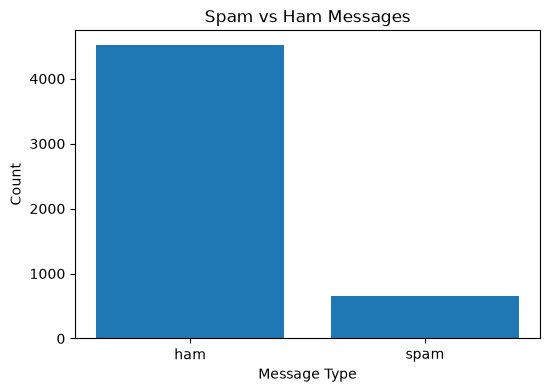

In [5]:
plt.figure(figsize=(6,4))

plt.bar(class_counts.index,
        class_counts.values)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

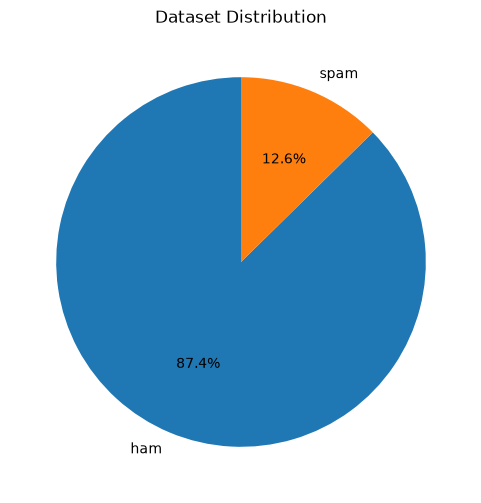

In [6]:
plt.figure(figsize=(6,6))

plt.pie(class_counts,
        labels=class_counts.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Dataset Distribution")

plt.show()

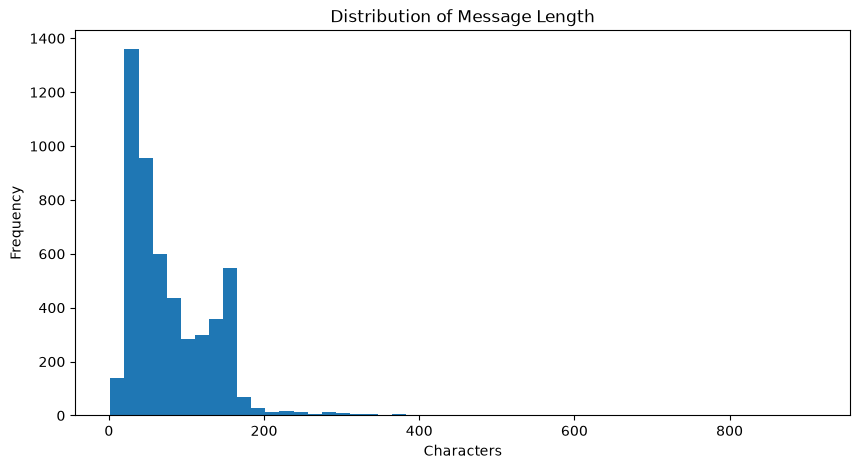

In [7]:
plt.figure(figsize=(10,5))

plt.hist(df["message_length"],
         bins=50)

plt.title("Distribution of Message Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

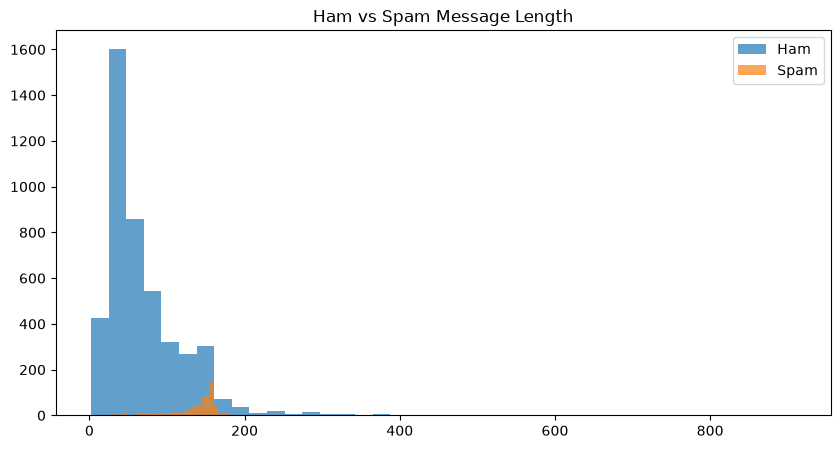

In [8]:
ham = df[df["label"]=="ham"]

spam = df[df["label"]=="spam"]

plt.figure(figsize=(10,5))

plt.hist(ham["message_length"],
         bins=40,
         alpha=0.7,
         label="Ham")

plt.hist(spam["message_length"],
         bins=40,
         alpha=0.7,
         label="Spam")

plt.legend()

plt.title("Ham vs Spam Message Length")

plt.show()

In [9]:
df.groupby("label")["message_length"].mean()

label
ham      70.459256
spam    137.891271
Name: message_length, dtype: float64

In [10]:
df.sort_values("message_length",
               ascending=False).head(10)

,label,message,message_length
1059,ham,For me the love should start with attraction.i...,910
1800,ham,The last thing i ever wanted to do was hurt yo...,790
2333,ham,Indians r poor but India is not a poor country...,632
1528,ham,How to Make a girl Happy? It's not at all diff...,611
2075,ham,Sad story of a Man - Last week was my b'day. M...,588
2281,ham,"Good evening Sir, hope you are having a nice d...",482
2863,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461
1463,ham,"Hey sweet, I was wondering when you had a mome...",458
2271,ham,A Boy loved a gal. He propsd bt she didnt mind...,450
2308,ham,Solve d Case : A Man Was Found Murdered On &l...,444


In [11]:
df.sort_values("message_length").head(10)

,label,message,message_length
1858,ham,Ok,2
4896,ham,\ER,3
1560,ham,645,3
3191,ham,:),3
256,ham,Yup,3
2096,ham,Ok.,3
2489,ham,Okie,4
4820,ham,U 2.,4
282,ham,Ok..,4
4019,ham,G.W.R,5


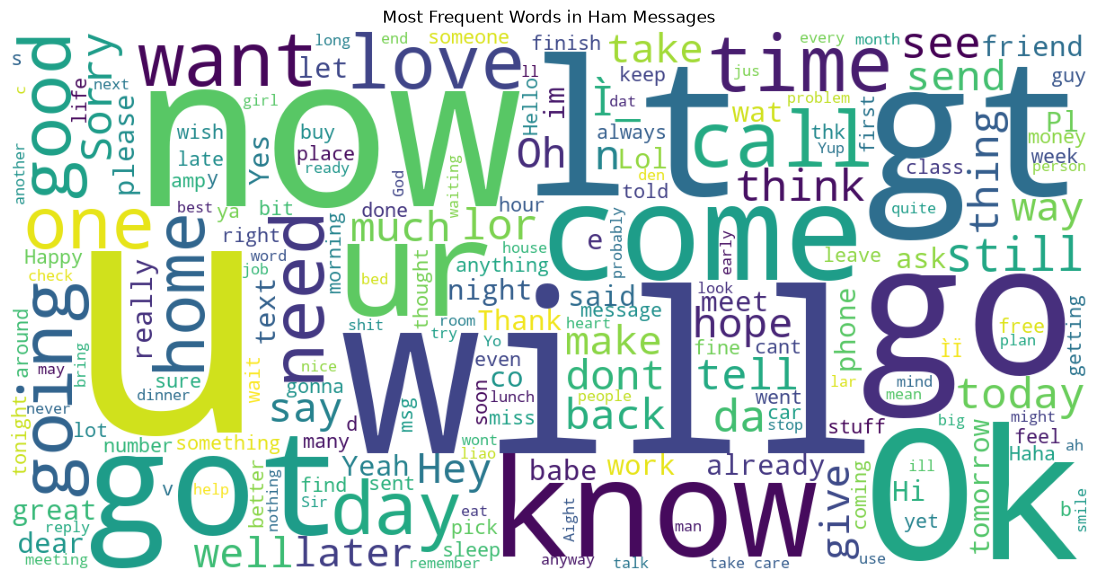

In [12]:
ham_text = " ".join(df[df["label"]=="ham"]["message"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Ham Messages")

plt.show()

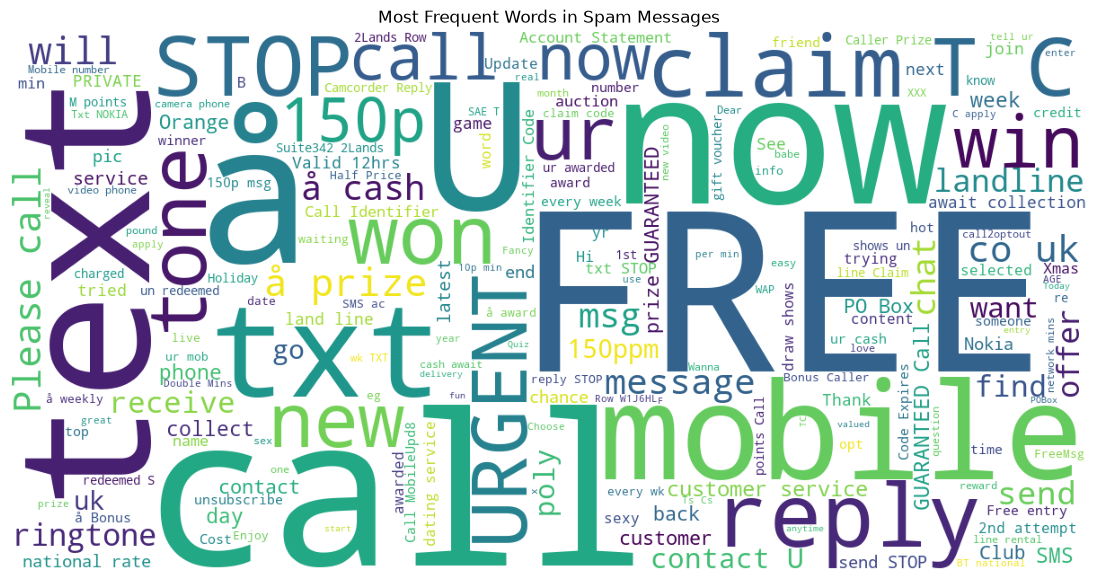

In [13]:
spam_text = " ".join(df[df["label"]=="spam"]["message"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Spam Messages")

plt.show()

In [14]:
df.to_csv("../dataset/processed/eda_dataset.csv", index=False)

print("EDA dataset saved successfully.")

EDA dataset saved successfully.
